# Which Pokemon have an Unusually High Status Compared to the Other Pokemon?

To find this out, I will be conducting an **observational study** because I have the entire dataset of the skills of each pokemon. By looking at each Pokemon's stats, I will be able to observe and see which ones amongst them are **outliers.** This will be analyzed using **quantitative data** so that I can look at the stats of each pokemon and then find out which Pokemon has a significantly higher status than the others. 

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pokemon = pd.read_csv("pokemon.csv")
pokemon.head()

,national_number,gen,english_name,japanese_name,primary_type,secondary_type,classification,percent_male,percent_female,height_m,...,evochain_1,evochain_2,evochain_3,evochain_4,evochain_5,evochain_6,gigantamax,mega_evolution,mega_evolution_alt,description
0,1,I,Bulbasaur,Fushigidane,grass,poison,Seed Pokémon,87.5,12.5,0.7,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,NaN,NaN,NaN,There is a plant seed on its back right from t...
1,2,I,Ivysaur,Fushigisou,grass,poison,Seed Pokémon,87.5,12.5,1.0,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,NaN,NaN,NaN,"When the bulb on its back grows large, it appe..."
2,3,I,Venusaur,Fushigibana,grass,poison,Seed Pokémon,87.5,12.5,2.0,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,Gigantamax Venusaur,Mega Venusaur,NaN,Its plant blooms when it is absorbing solar en...
3,4,I,Charmander,Hitokage,fire,NaN,Lizard Pokémon,87.5,12.5,0.6,...,Level,Charmeleon,Level,Charizard,NaN,NaN,NaN,NaN,NaN,It has a preference for hot things. When it ra...
4,5,I,Charmeleon,Lizardo,fire,NaN,Flame Pokémon,87.5,12.5,1.1,...,Level,Charmeleon,Level,Charizard,NaN,NaN,NaN,NaN,NaN,"It has a barbaric nature. In battle, it whips ..."


## Overview:

In [2]:
pokemon.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 55 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   national_number     1025 non-null   int64  
 1   gen                 1025 non-null   str    
 2   english_name        1025 non-null   str    
 3   japanese_name       1025 non-null   str    
 4   primary_type        1025 non-null   str    
 5   secondary_type      526 non-null    str    
 6   classification      1025 non-null   str    
 7   percent_male        870 non-null    float64
 8   percent_female      870 non-null    float64
 9   height_m            1025 non-null   float64
 10  weight_kg           1025 non-null   float64
 11  capture_rate        1025 non-null   str    
 12  base_egg_steps      1025 non-null   int64  
 13  hp                  1025 non-null   int64  
 14  attack              1025 non-null   int64  
 15  defense             1025 non-null   int64  
 16  sp_attack        

In [11]:
pokemon["hp"].tolist()

[45,
 60,
 80,
 39,
 58,
 78,
 44,
 59,
 79,
 45,
 50,
 60,
 40,
 45,
 65,
 40,
 63,
 83,
 30,
 55,
 40,
 65,
 35,
 60,
 35,
 60,
 50,
 75,
 55,
 70,
 90,
 46,
 61,
 81,
 70,
 95,
 38,
 73,
 115,
 140,
 40,
 75,
 45,
 60,
 75,
 35,
 60,
 60,
 70,
 10,
 35,
 40,
 65,
 50,
 80,
 40,
 65,
 55,
 90,
 40,
 65,
 90,
 25,
 40,
 55,
 70,
 80,
 90,
 50,
 65,
 80,
 40,
 80,
 40,
 55,
 80,
 50,
 65,
 90,
 95,
 25,
 50,
 52,
 35,
 60,
 65,
 90,
 80,
 105,
 30,
 50,
 30,
 45,
 60,
 35,
 60,
 85,
 30,
 55,
 40,
 60,
 60,
 95,
 50,
 60,
 50,
 50,
 90,
 40,
 65,
 80,
 105,
 250,
 65,
 105,
 30,
 55,
 45,
 80,
 30,
 60,
 40,
 70,
 65,
 65,
 65,
 65,
 75,
 20,
 95,
 130,
 48,
 55,
 130,
 65,
 65,
 65,
 35,
 70,
 30,
 60,
 80,
 160,
 90,
 90,
 90,
 41,
 61,
 91,
 106,
 100,
 45,
 60,
 80,
 39,
 58,
 78,
 50,
 65,
 85,
 35,
 85,
 60,
 100,
 40,
 55,
 40,
 70,
 85,
 75,
 125,
 20,
 50,
 90,
 35,
 55,
 40,
 65,
 55,
 70,
 90,
 75,
 70,
 100,
 70,
 90,
 35,
 55,
 75,
 55,
 30,
 75,
 65,
 55,
 95,
 65,
 95,
 

## Visuals: 

### Histogram:

<Axes: xlabel='hp', ylabel='Count'>

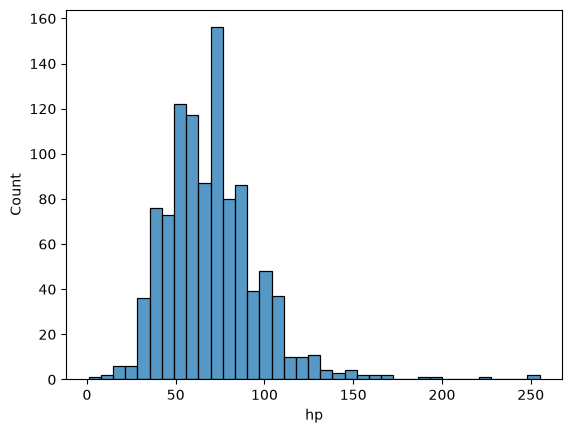

In [5]:
sns.histplot(data=pokemon, x="hp")

### Box Plot: 

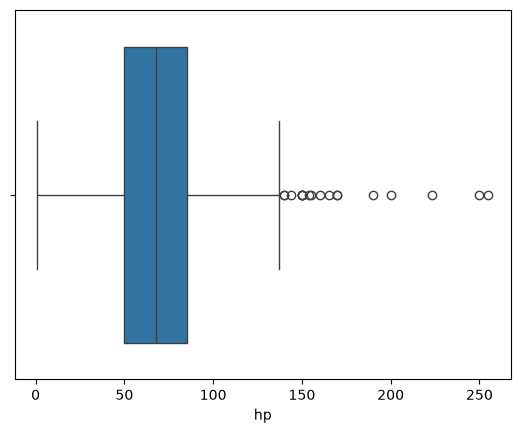

In [6]:
sns.boxplot(data=pokemon, x="hp")
plt.show()

## Analysis:

In [9]:
Q1 = pokemon["hp"].quantile(0.25)
Q3 = pokemon["hp"].quantile(0.75)

IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

pokemon[pokemon["hp"] > upper][["english_name", "hp"]]

,english_name,hp
39,Wigglytuff,140
112,Chansey,250
142,Snorlax,160
201,Wobbuffet,190
241,Blissey,255
288,Slaking,150
296,Hariyama,144
320,Wailord,170
425,Drifblim,150
486,Giratina,150


# Conclusion: 

After evauating my data, I checked into each of the Pokemon's HP status to look at which ones would be unusally greater than the rest. Looking at my histogram and box plot, I noticed that there were indeed many outliers to the data and the majority of it were the ones that were above around the 140 range, which were outside the interquartile range area. Two of the highest outliers were Chansey and Blissey with an HP of 250 and 255, which were significantly larger than the others, making them two of the furthest outliers. In total, there were 18 outliers that had an HP of 140 and higher. 